# 🏨 Hotel Booking Analysis using Python

## Project Objective

This project analyzes hotel booking data to understand customer booking behavior, cancellation patterns, seasonal demand, pricing trends, and operational performance.

The goal is to derive actionable business insights that can help hotels optimize occupancy, improve revenue management, reduce booking cancellations, and enhance customer satisfaction.

# 📚 Phase 1: Data Understanding

## Step 1: Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Set Plot Style
sns.set_style("whitegrid")

### Observation

The required Python libraries were successfully imported.

### Insights

- Pandas and NumPy will be used for data manipulation.
- Matplotlib and Seaborn will be used to create visualizations.
- Display settings are configured to show all columns for easier exploration.

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("C:/Users/VRAJB/Downloads/archive (1)/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Observation

The first five records of the hotel booking dataset have been displayed.

### Insights

- The dataset contains booking-related information such as hotel type, customer details, stay duration, pricing, and booking status.
- Displaying the first few rows helps verify that the dataset has been loaded correctly.

## Step 3: Check Dataset Dimensions

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 119390
Columns: 32


### Observation

The total number of rows and columns in the dataset has been identified.

### Insights

- A large number of observations improves the reliability of the analysis.
- The number of columns indicates the variety of information available for exploration.

## Step 4: Explore Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Observation

The dataset information displays the data type, non-null count, and memory usage for each column.

### Insights

- Identifies numerical and categorical variables.
- Highlights columns with missing values.
- Helps determine if any data type conversions are required.

## Step 5: Display Column Names

In [5]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

### Observation

The names of all variables in the dataset have been displayed.

### Insights

- Reviewing column names provides an overview of available business information.
- It helps identify key variables for subsequent analysis.

## Step 6: Identify Missing Values

In [6]:
missing = df.isnull().sum()

missing[missing > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

### Observation

The output lists only the columns containing missing values.

### Insights

- Missing values can impact the quality of analysis.
- Columns with missing data will be handled during the data cleaning phase.

## Step 7: Check for Duplicate Records

In [7]:
df.duplicated().sum()

np.int64(31994)

### Observation

The number of duplicate records has been calculated.

### Insights

- Duplicate records may bias the analysis.
- If duplicates exist, they will be removed in the cleaning phase.

## Step 8: Generate Descriptive Statistics

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


### Observation

Summary statistics have been generated for all numerical variables.

### Insights

- The output provides measures such as mean, standard deviation, minimum, maximum, and quartiles.
- These statistics help identify data ranges, variability, and potential outliers.

## Step 9: Display Random Sample Records

In [9]:
df.sample(5, random_state=42)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30946,Resort Hotel,0,203,2016,December,49,2,2,5,2,0.0,0,BB,GBR,Direct,Direct,0,0,0,F,F,4,No Deposit,250.0,NaN,0,Transient,66.8,0,0,Check-Out,2016-12-09
40207,City Hotel,1,82,2015,July,29,16,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,76.5,0,0,Canceled,2015-07-16
103708,City Hotel,0,25,2016,December,53,27,0,3,3,0.0,0,BB,BRA,Offline TA/TO,TA/TO,0,0,0,A,K,2,No Deposit,220.0,NaN,0,Transient-Party,60.0,0,1,Check-Out,2016-12-30
85144,City Hotel,0,1,2016,March,11,9,0,1,1,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient-Party,95.0,0,0,Check-Out,2016-03-10
109991,City Hotel,0,70,2017,April,16,16,2,2,2,0.0,0,SC,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,108.0,0,0,Check-Out,2017-04-20


### Observation

A random sample of records has been displayed.

### Insights

- Random sampling helps verify data quality across different observations.
- It provides a broader view of the dataset beyond the first few rows.

# 🧹 Phase 2: Data Cleaning

## Step 1: Create a Copy of the Original Dataset

In [10]:
clean_df=df.copy()

### Observation

A copy of the original dataset has been created.

### Insights

- The original dataset remains unchanged.
- All cleaning operations will be performed on the copied dataset.
- This is a standard best practice in data analysis.

## Step 2: Identify Missing Values

In [11]:
missing_values = clean_df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

### Observation

The output displays only the columns containing missing values.

### Insights

- Missing values can reduce the quality of analysis.
- Each column should be evaluated separately before choosing an appropriate treatment.

## Step 3: Calculate Missing Value Percentage

In [12]:
missing_percentage = (clean_df.isnull().sum() / len(clean_df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

### Observation

The percentage of missing values has been calculated for each column.

### Insights

- Columns with very high missing percentages should be carefully evaluated.
- Columns with only a few missing values can usually be imputed.

## Step 4: Handle Missing Values

In [13]:
# Fill missing values
clean_df['children'].fillna(0, inplace=True)
clean_df['country'].fillna('Unknown', inplace=True)
clean_df['agent'].fillna(0, inplace=True)
clean_df['company'].fillna(0, inplace=True)

### Observation

Missing values have been handled using appropriate replacements.

### Insights

- Missing values in **children** were replaced with 0, assuming no children were recorded.
- Missing values in **country** were labeled as "Unknown" to preserve records.
- Missing values in **agent** and **company** were replaced with 0, indicating no associated travel agent or company.
- These replacements allow the dataset to remain complete for analysis.

## Step 5: Verify Missing Values

In [14]:
clean_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

### Observation

The dataset has been checked again for missing values.

### Insights

- All missing values should now be resolved.
- The dataset is more reliable for further analysis.

## Step 6: Check Duplicate Records

In [15]:
clean_df.duplicated().sum()

np.int64(31994)

### Observation

The number of duplicate rows has been calculated.

### Insights

- Duplicate records can distort analytical results.
- If duplicates exist, they should be removed.

## Step 7: Remove Duplicate Records

In [16]:
clean_df.drop_duplicates(inplace=True)

clean_df.duplicated().sum()

np.int64(0)

### Observation

Duplicate records have been removed from the dataset.

### Insights

- Removing duplicate records improves data quality.
- Each row now represents a unique booking.

## Step 8: Verify Data Types

In [19]:
clean_df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

### Observation

The data types of all variables have been displayed.

### Insights

- Numerical variables are ready for statistical analysis.
- Categorical variables can be used for grouping and visualization.
- Data types should match the nature of each feature.

## Step 9: Convert Reservation Status Date to Datetime

In [20]:
clean_df['reservation_status_date'] = pd.to_datetime(
    clean_df['reservation_status_date']
)

clean_df['reservation_status_date'].head()

0   2015-07-01
1   2015-07-01
2   2015-07-02
3   2015-07-02
4   2015-07-03
Name: reservation_status_date, dtype: datetime64[ns]

### Observation

The reservation status date has been converted to datetime format.

### Insights

- Datetime conversion enables time-based analysis.
- This supports trend analysis and feature engineering in later phases.

# 📊 Phase 3: Univariate Analysis

## Step 1: Identify Numerical and Categorical Variables

In [21]:
numerical_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = clean_df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

Categorical Columns:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status'],
      dtype='object')


### Observation

The dataset has been divided into numerical and categorical variables.

### Insights

- Numerical variables will be analyzed using histograms and box plots.
- Categorical variables will be analyzed using count plots.
- This classification helps select the appropriate visualization for each variable.

## Step 2: Analyze Hotel Type Distribution

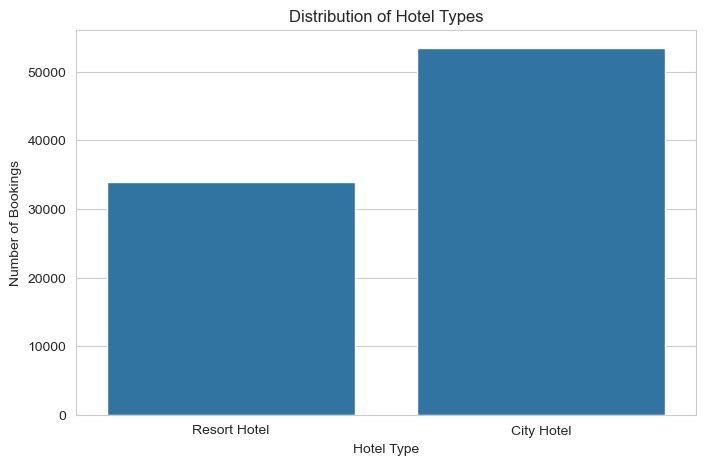

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=clean_df, x='hotel')

plt.title("Distribution of Hotel Types")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

### Observation

The chart displays the number of bookings for each hotel type.

### Insights

- Compare booking volume between Resort Hotels and City Hotels.
- The hotel type with more bookings represents the larger share of demand.

## Step 3: Analyze Booking Cancellation Status

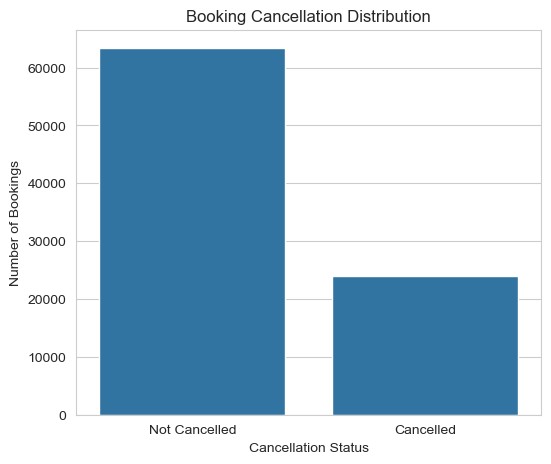

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(data=clean_df, x='is_canceled')

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.xticks([0,1],["Not Cancelled","Cancelled"])

plt.show()

### Observation

The chart compares cancelled and non-cancelled bookings.

### Insights

- A high cancellation rate may negatively affect occupancy and revenue.
- Hotels can use this information to improve booking policies.

## Step 4: Analyze Monthly Booking Trends

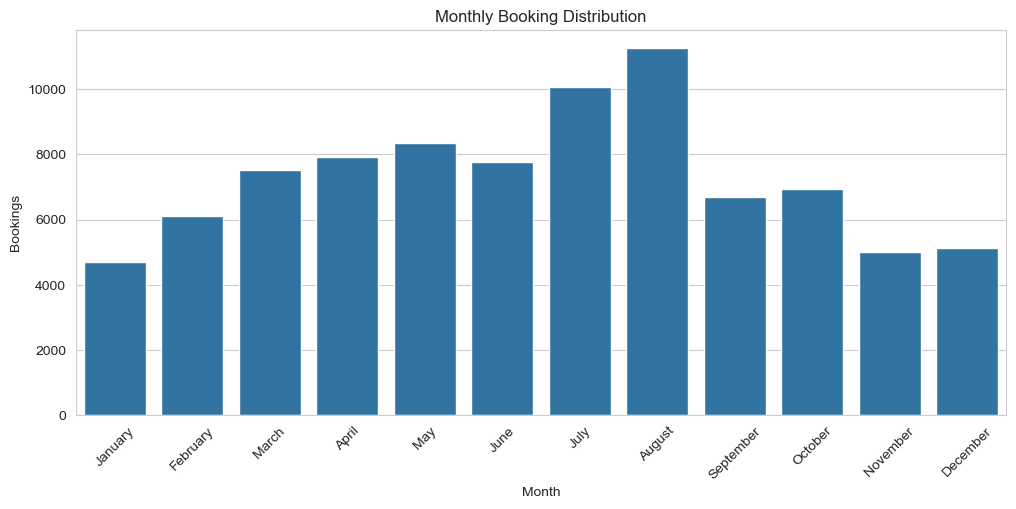

In [24]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=clean_df,
    x='arrival_date_month',
    order=month_order
)

plt.xticks(rotation=45)
plt.title("Monthly Booking Distribution")
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.show()

### Observation

The chart shows the number of bookings received each month.

### Insights

- Identify peak and off-peak seasons.
- Seasonal demand can guide staffing, pricing, and promotional strategies.

## Step 5: Analyze Lead Time Distribution

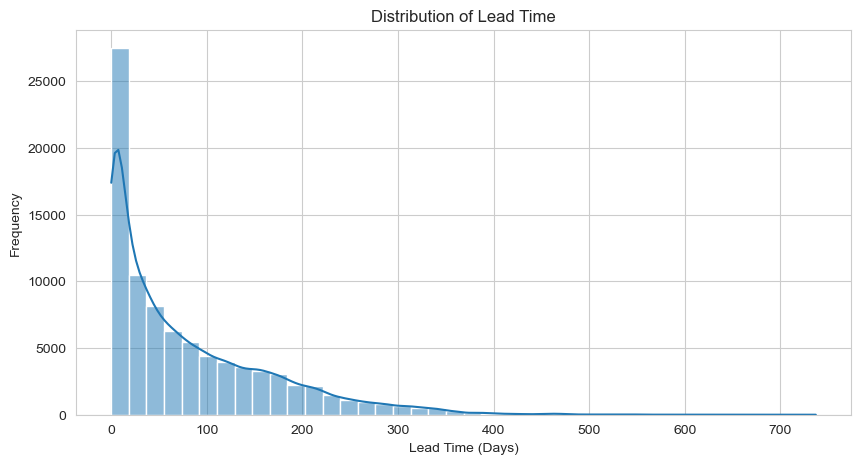

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(clean_df['lead_time'], bins=40, kde=True)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

### Observation

The histogram displays how far in advance customers make bookings.

### Insights

- Short lead times indicate last-minute bookings.
- Long lead times may require flexible cancellation and pricing strategies.

## Step 6: Analyze Average Daily Rate (ADR)

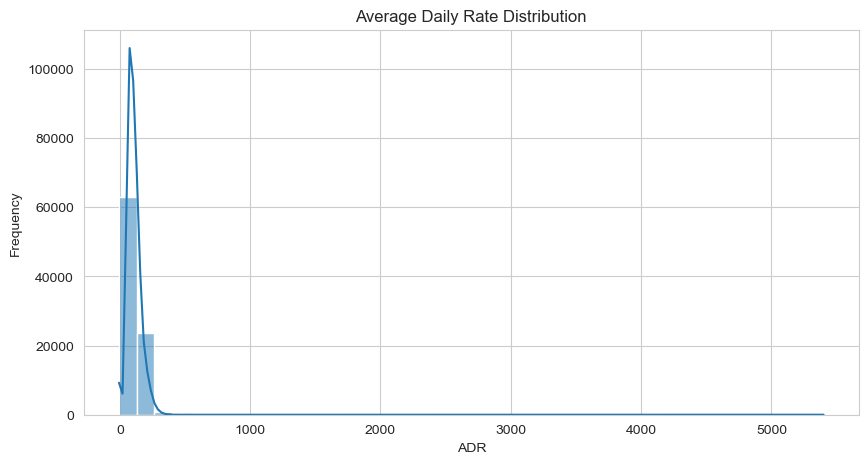

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(clean_df['adr'], bins=40, kde=True)

plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

### Observation

The histogram illustrates the distribution of the Average Daily Rate.

### Insights

- ADR reflects hotel pricing patterns.
- Extremely high or low ADR values should be investigated.

## Step 7: Analyze Market Segments

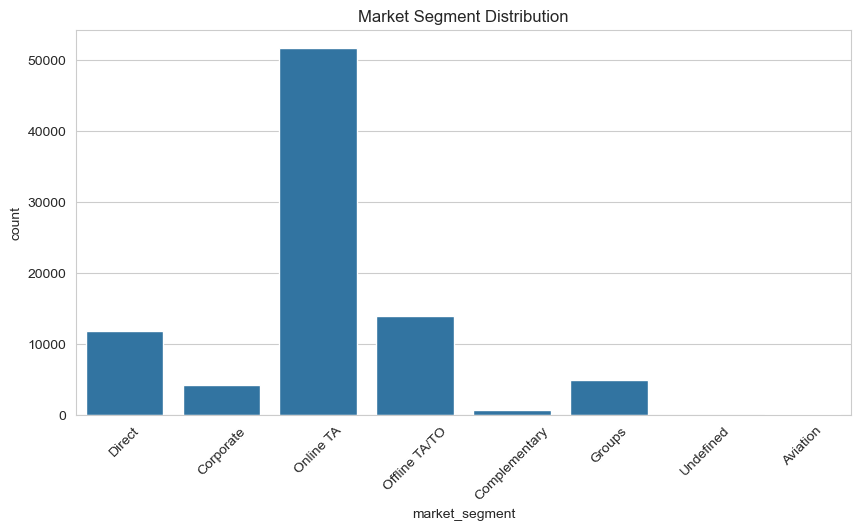

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=clean_df,
    x='market_segment'
)

plt.xticks(rotation=45)
plt.title("Market Segment Distribution")
plt.show()

### Observation

The chart displays bookings across different market segments.

### Insights

- The dominant market segment contributes the highest share of bookings.
- Understanding market segments helps target marketing efforts effectively.

## Step 8: Analyze Customer Types

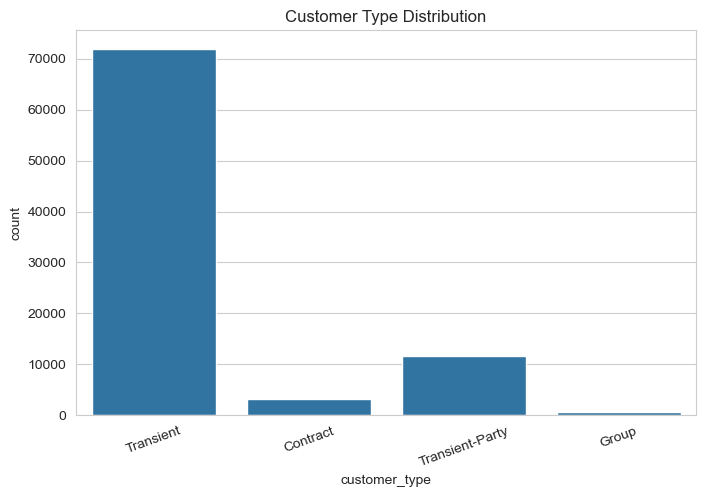

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x='customer_type'
)

plt.title("Customer Type Distribution")
plt.xticks(rotation=20)
plt.show()

### Observation

The chart compares the number of bookings across customer types.

### Insights

- Identifies the most common customer group.
- Helps hotels tailor services and loyalty programs.

## Step 9: Analyze Deposit Types

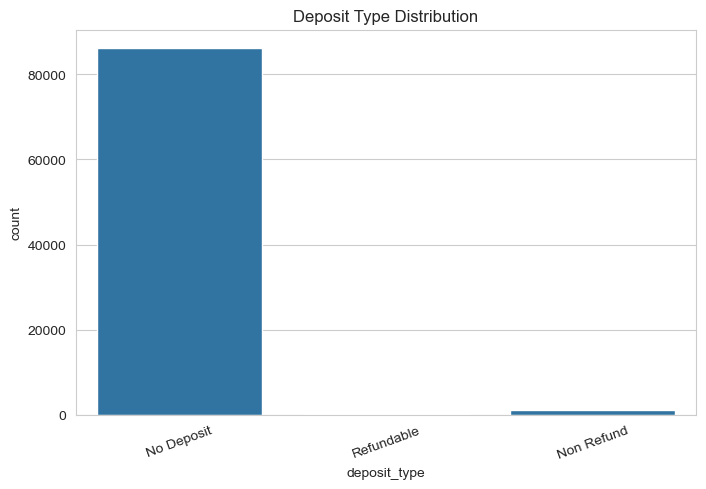

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x='deposit_type'
)

plt.title("Deposit Type Distribution")
plt.xticks(rotation=20)
plt.show()

### Observation

The chart shows the frequency of each deposit type.

### Insights

- Deposit policies influence booking behavior and cancellation risk.
- Hotels can evaluate whether current deposit policies are effective.

# 📊 Phase 4: Bivariate Analysis

## Step 1: Analyze Hotel Type vs Booking Cancellation

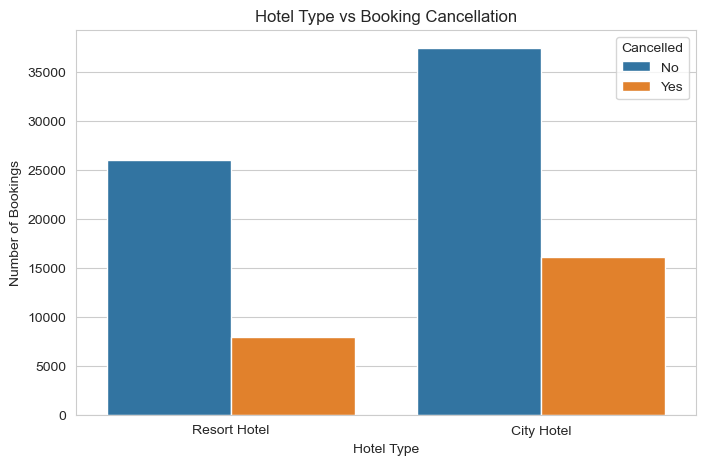

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x='hotel',
    hue='is_canceled'
)

plt.title("Hotel Type vs Booking Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Cancelled", labels=["No", "Yes"])

plt.show()

### Observation

The chart compares booking cancellations across different hotel types.

### Insights

- Compare cancellation rates between Resort Hotels and City Hotels.
- A higher cancellation rate may indicate the need for revised booking or cancellation policies.

## Step 2: Analyze Lead Time by Booking Status

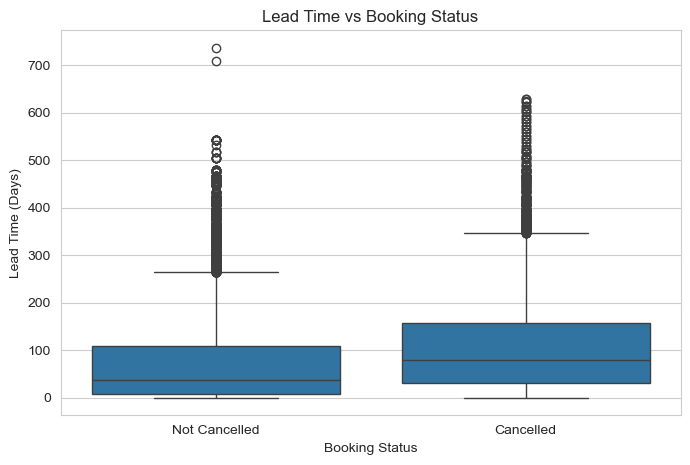

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x='is_canceled',
    y='lead_time'
)

plt.xticks([0,1],["Not Cancelled","Cancelled"])

plt.title("Lead Time vs Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (Days)")

plt.show()

### Observation

The box plot compares lead times for cancelled and non-cancelled bookings.

### Insights

- Longer lead times often increase the likelihood of cancellation.
- Hotels can implement reminder emails or flexible pricing to reduce cancellations.

## Step 3: Compare ADR Across Market Segments

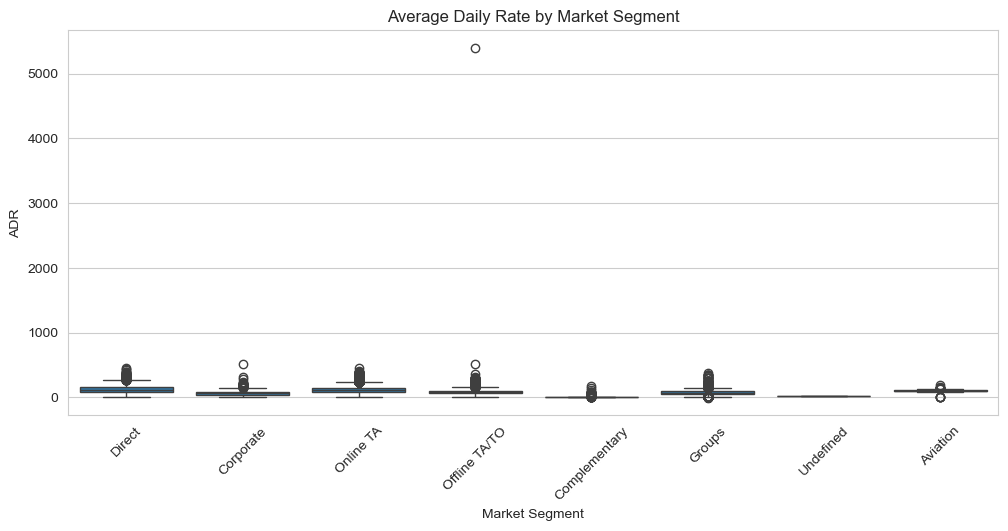

In [32]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=clean_df,
    x='market_segment',
    y='adr'
)

plt.xticks(rotation=45)

plt.title("Average Daily Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("ADR")

plt.show()

### Observation

The chart compares room prices across market segments.

### Insights

- Premium market segments generally have higher ADR.
- Segments with lower ADR may require pricing optimization.

## Step 4: Analyze Customer Type vs Average Daily Rate

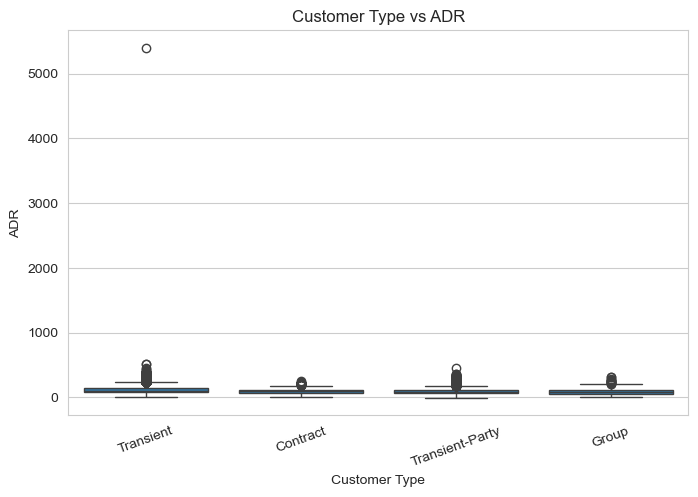

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x='customer_type',
    y='adr'
)

plt.xticks(rotation=20)

plt.title("Customer Type vs ADR")
plt.xlabel("Customer Type")
plt.ylabel("ADR")

plt.show()

### Observation

The chart compares room rates paid by different customer types.

### Insights

- Different customer groups may have distinct pricing patterns.
- This information supports pricing and loyalty program decisions.

## Step 5: Analyze Deposit Type vs Booking Cancellation

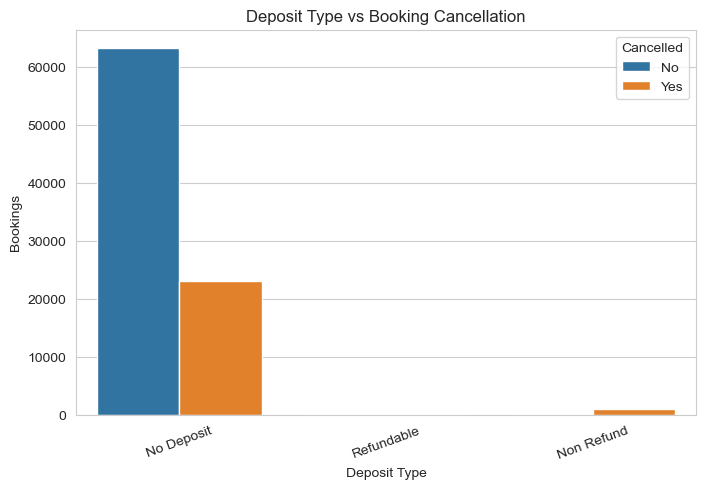

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x='deposit_type',
    hue='is_canceled'
)

plt.title("Deposit Type vs Booking Cancellation")
plt.xticks(rotation=20)
plt.xlabel("Deposit Type")
plt.ylabel("Bookings")
plt.legend(title="Cancelled", labels=["No","Yes"])

plt.show()

### Observation

The chart compares cancellation counts across deposit types.

### Insights

- Deposit policies may significantly influence cancellation behavior.
- Hotels can evaluate whether requiring deposits reduces cancellations.

## Step 6: Top 10 Countries by Number of Bookings

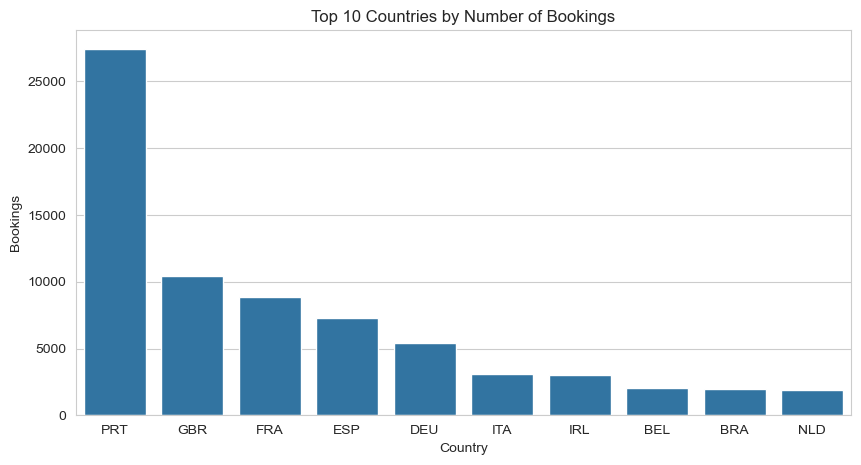

In [35]:
top_countries = clean_df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country")
plt.ylabel("Bookings")

plt.show()

### Observation

The chart displays the top 10 countries contributing the highest number of bookings.

### Insights

- Identifying key source markets helps prioritize marketing efforts.
- Hotels can tailor promotions to countries with the highest booking volumes.

## Step 7: Analyze Reserved Room Type vs ADR

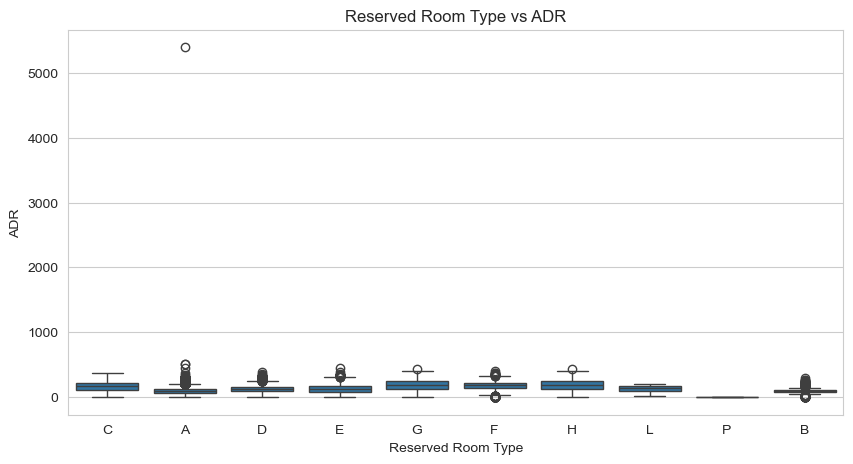

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=clean_df,
    x='reserved_room_type',
    y='adr'
)

plt.title("Reserved Room Type vs ADR")
plt.xlabel("Reserved Room Type")
plt.ylabel("ADR")

plt.show()

### Observation

The box plot compares room prices across reserved room types.

### Insights

- Premium room types generally command higher ADR.
- Understanding room pricing helps optimize revenue management.

# 📊 Phase 5: Multivariate Analysis

## Step 1: Correlation Heatmap

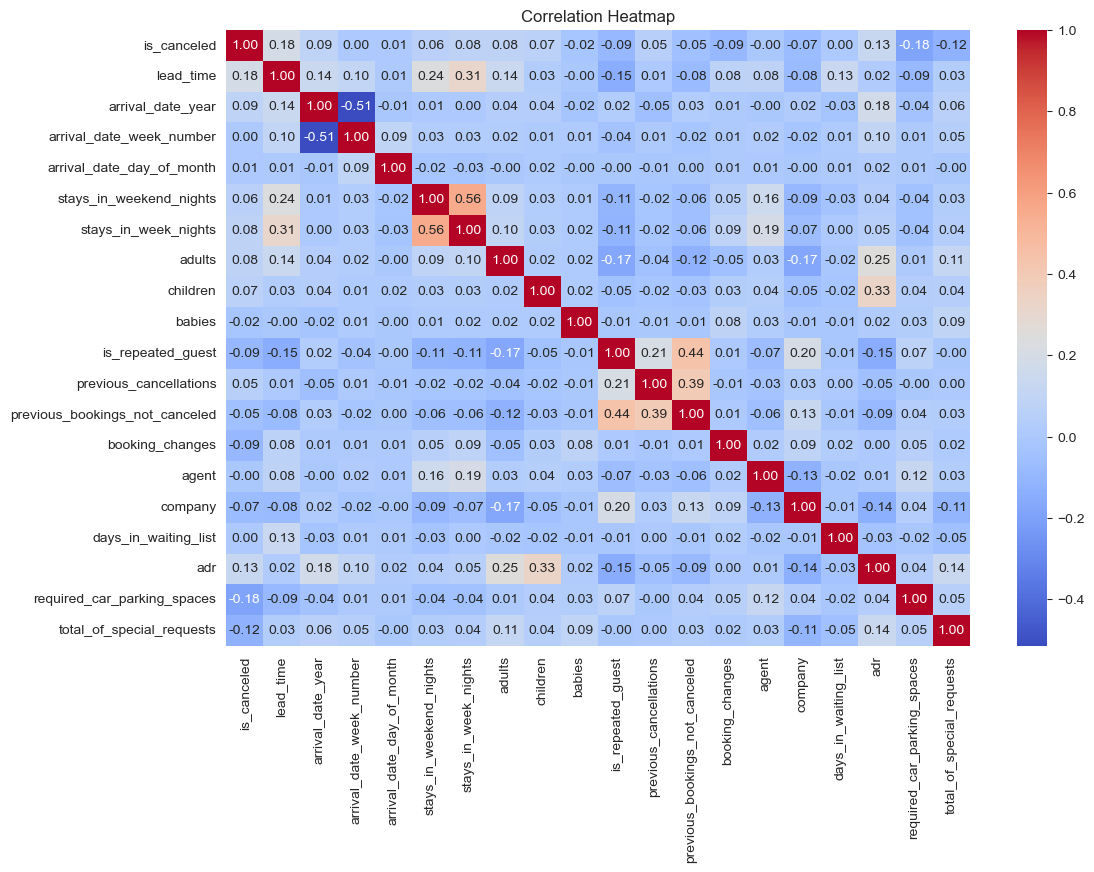

In [37]:
plt.figure(figsize=(12,8))

numeric_df = clean_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap displays the correlation between all numerical variables.

### Insights

- Strong positive correlations indicate variables that increase together.
- Negative correlations indicate inverse relationships.
- Weak correlations suggest little or no linear relationship.
- The heatmap helps identify important variables for business analysis.

## Step 2: Monthly Bookings by Hotel Type

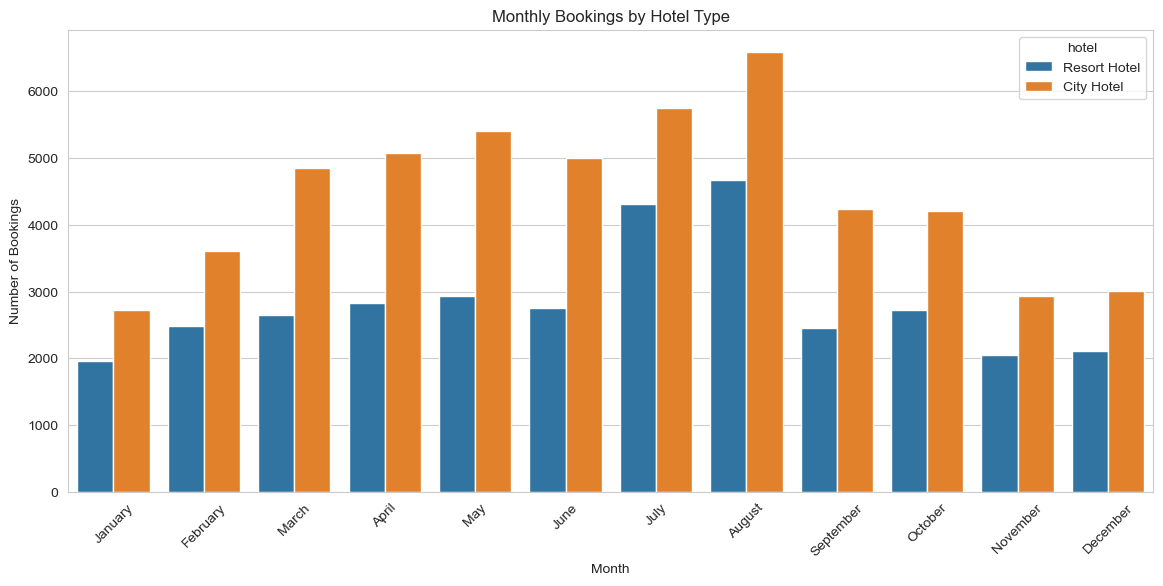

In [38]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(14,6))

sns.countplot(
    data=clean_df,
    x='arrival_date_month',
    hue='hotel',
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Monthly Bookings by Hotel Type")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.show()

### Observation

The chart compares monthly booking volumes for Resort Hotels and City Hotels.

### Insights

- Peak booking months can be identified for each hotel type.
- Seasonal demand patterns help optimize staffing and pricing.
- Hotels can prepare promotional campaigns during low-demand periods.

## Step 3: ADR by Market Segment and Hotel Type

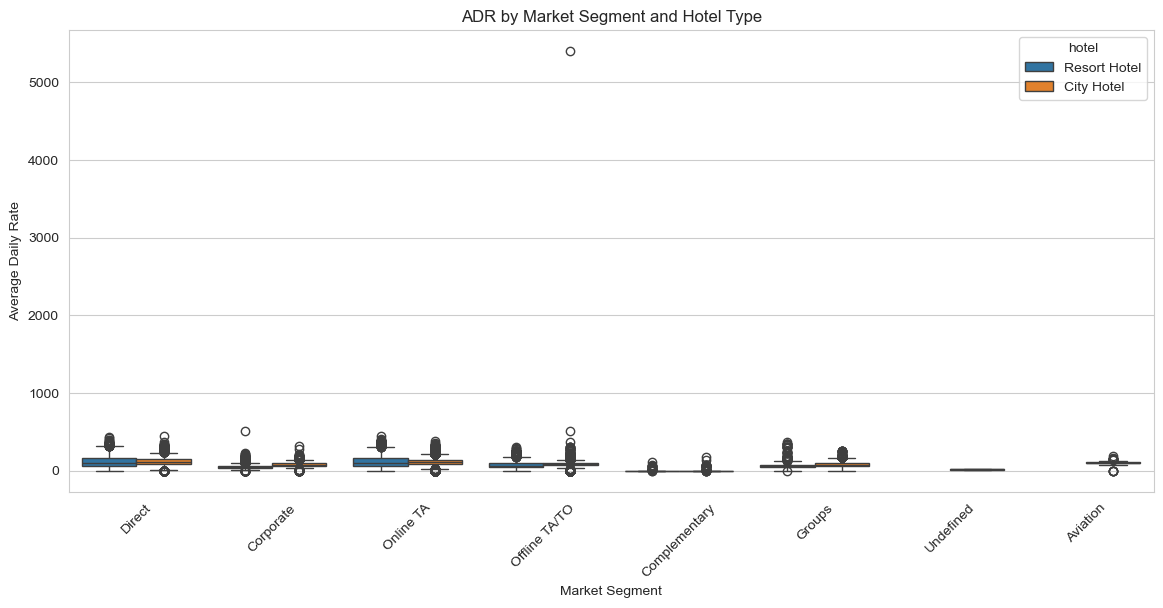

In [39]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=clean_df,
    x='market_segment',
    y='adr',
    hue='hotel'
)

plt.xticks(rotation=45)

plt.title("ADR by Market Segment and Hotel Type")
plt.xlabel("Market Segment")
plt.ylabel("Average Daily Rate")

plt.show()

### Observation

The chart compares pricing across market segments for both hotel types.

### Insights

- Premium customer segments may pay higher room rates.
- Hotels can optimize pricing strategies based on market segment performance.

## Step 4: Deposit Type, Customer Type and Cancellation

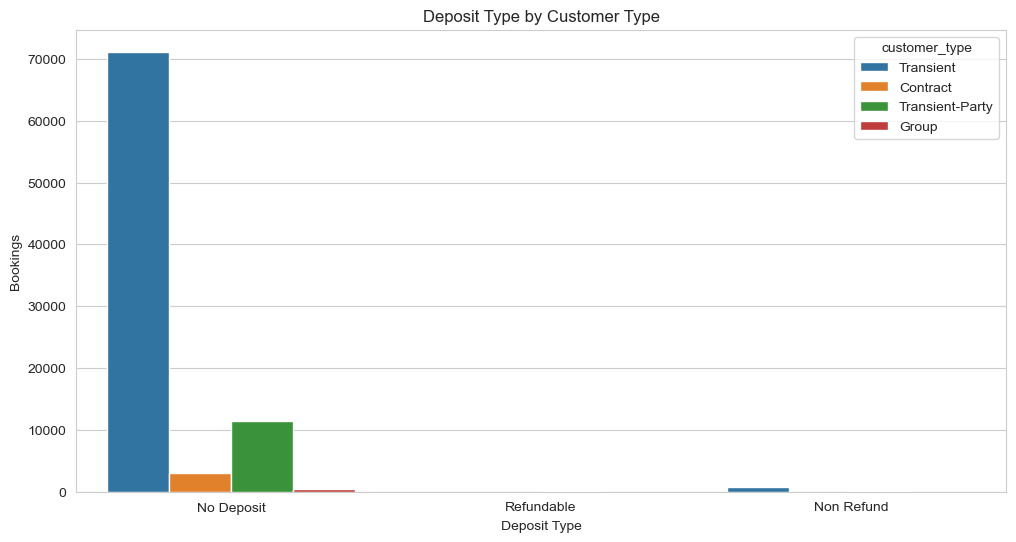

In [40]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=clean_df,
    x='deposit_type',
    hue='customer_type'
)

plt.title("Deposit Type by Customer Type")
plt.xlabel("Deposit Type")
plt.ylabel("Bookings")

plt.show()

### Observation

The chart compares customer types across different deposit policies.

### Insights

- Different customer groups show varying preferences for deposit types.
- This information can support customized booking policies.

## Step 5: Lead Time by Hotel Type and Booking Status

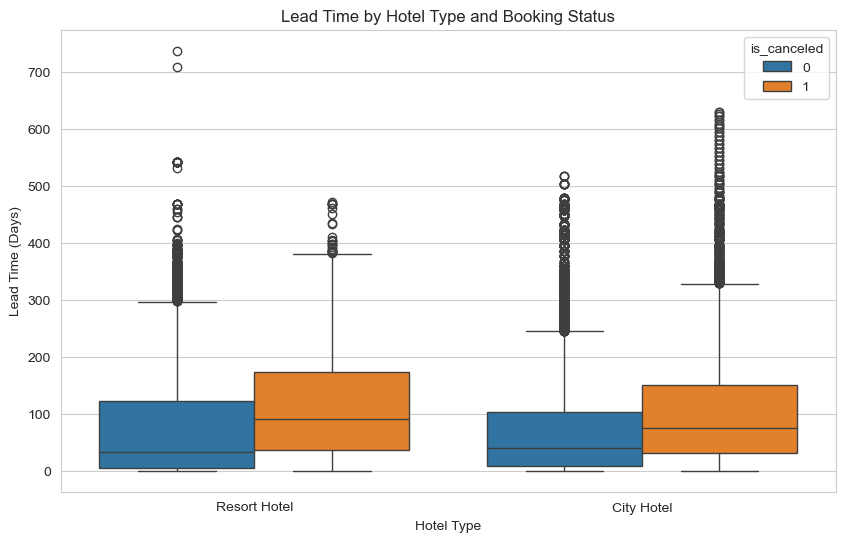

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=clean_df,
    x='hotel',
    y='lead_time',
    hue='is_canceled'
)

plt.title("Lead Time by Hotel Type and Booking Status")
plt.xlabel("Hotel Type")
plt.ylabel("Lead Time (Days)")

plt.show()

### Observation

The box plot compares lead times for cancelled and non-cancelled bookings across hotel types.

### Insights

- Longer lead times often correspond to higher cancellation rates.
- Hotels can introduce reminder notifications or flexible cancellation policies to reduce cancellations.

## Step 6: Average ADR by Month and Hotel Type

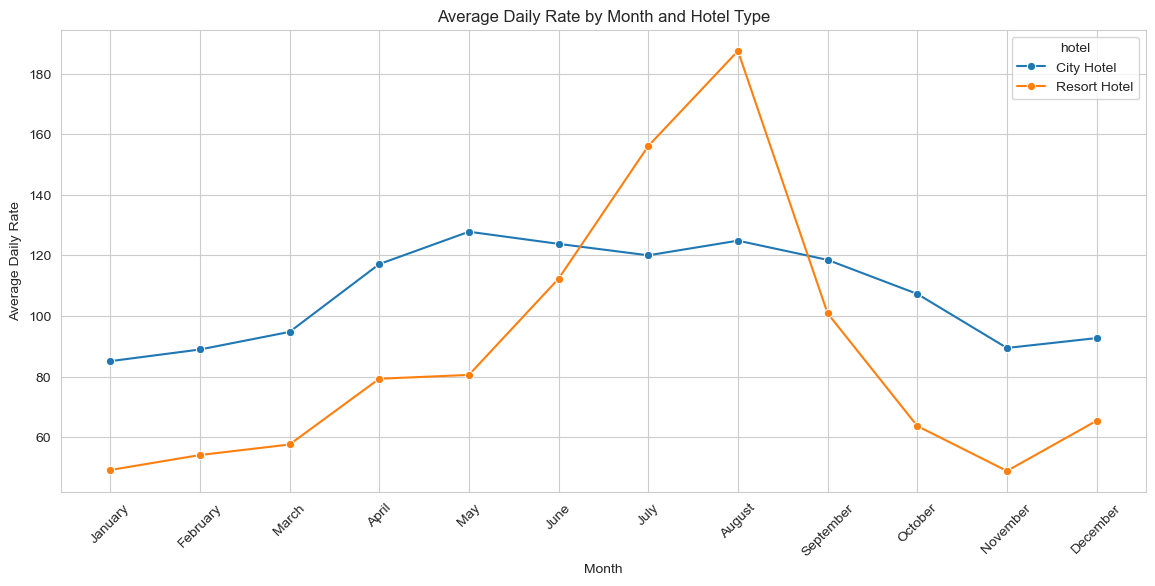

In [42]:
monthly_adr = clean_df.groupby(
    ['arrival_date_month', 'hotel']
)['adr'].mean().reset_index()

monthly_adr['arrival_date_month'] = pd.Categorical(
    monthly_adr['arrival_date_month'],
    categories=month_order,
    ordered=True
)

monthly_adr = monthly_adr.sort_values('arrival_date_month')

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_adr,
    x='arrival_date_month',
    y='adr',
    hue='hotel',
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Average Daily Rate by Month and Hotel Type")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate")

plt.show()

### Observation

The line chart illustrates monthly ADR trends for both hotel types.

### Insights

- Hotels can identify months with peak pricing.
- Seasonal pricing strategies can maximize revenue during high-demand periods.

# 💼 Phase 6: Business Insights

## Step 1: Booking Trends

### Observation

Analyze the monthly booking distribution chart.

### Business Insight

- The hotel experiences clear seasonal demand, with certain months receiving significantly more bookings than others.
- During peak months, hotels should increase staffing, room availability, and dynamic pricing.
- During low-demand months, promotional offers can help improve occupancy.

## Step 2: Booking Cancellation Insights

### Observation

Review the booking cancellation charts.

### Business Insight

- A significant portion of bookings are cancelled.
- Long lead-time bookings tend to have a higher cancellation risk.
- Reducing cancellations can directly improve occupancy and revenue.

## Step 3: Hotel Type Performance

### Observation

Compare bookings between Resort Hotels and City Hotels.

### Business Insight

- One hotel type receives more bookings than the other.
- Understanding customer preference helps allocate marketing budgets more effectively.

## Step 4: Average Daily Rate (ADR)

### Observation

Analyze the ADR distribution and ADR comparison charts.

### Business Insight

- Room prices vary across customer groups and market segments.
- Premium segments contribute higher revenue.
- Hotels can use dynamic pricing during high-demand periods.


## Step 5: Market Segment Performance


### Observation

Review the Market Segment chart.

### Business Insight

- A few market segments contribute the majority of bookings.
- Marketing efforts should prioritize these high-performing segments.

## Step 6: Customer Type Analysis

### Observation

Analyze the customer type distribution.

### Business Insight

- Most bookings come from one or two customer types.
- Personalized offers and loyalty programs can improve repeat bookings.

## Step 7: Country-wise Booking Analysis

### Observation

Review the Top Countries chart.

### Business Insight

- A small number of countries generate most bookings.
- Country-specific marketing campaigns can improve international bookings.

## Step 8: Room Type Analysis

### Observation

Analyze room type distribution and ADR.

### Business Insight

- Premium room categories generate higher revenue.
- Understanding room demand helps optimize inventory and pricing.

## Step 9: Deposit Policy Analysis

### Observation

Compare deposit types with cancellations.

### Business Insight

- Deposit policies influence booking behavior.
- Appropriate deposit requirements can reduce cancellation rates while maintaining customer convenience.

# 📌 Executive Summary

## Key Business Findings

- Booking demand varies significantly throughout the year.
- Cancellation behavior is influenced by lead time and booking policies.
- Customer segments contribute differently to hotel revenue.
- ADR differs across hotel types and market segments.
- Certain countries generate a larger share of bookings.
- Pricing and promotional strategies should adapt to seasonal demand.
- Data-driven decision-making can improve occupancy, profitability, and customer satisfaction.

# 💡 Phase 7: Business Recommendations

## Step 1: Optimize Pricing Strategy

### Recommendation

Implement dynamic pricing based on seasonal demand, hotel type, and market segment.

### Why?

- Demand fluctuates across months.
- Higher demand periods allow premium pricing.
- Lower demand periods can be supported with promotional discounts.

### Expected Business Impact

- Increase revenue per booking.
- Improve occupancy during off-peak seasons.

## Step 2: Reduce Booking Cancellations

### Recommendation

Review cancellation policies for bookings made far in advance and introduce reminder notifications before check-in.

### Why?

- Long lead-time bookings are more likely to be cancelled.
- Timely reminders can reduce unnecessary cancellations.

### Expected Business Impact

- Higher occupancy rates.
- More predictable revenue.

## Step 3: Focus on High-Performing Market Segments

### Recommendation

Allocate more marketing budget to market segments that generate the highest number of bookings.

### Why?

- These segments already show strong demand.
- Investing in successful channels provides a better return on investment.

### Expected Business Impact

- Increased bookings.
- Improved marketing efficiency.

## Step 4: Improve Customer Retention

### Recommendation

Develop loyalty programs and personalized offers for frequent guests.

### Why?

- Returning customers are generally less expensive to retain than acquiring new ones.
- Personalized experiences increase customer satisfaction.

### Expected Business Impact

- Higher repeat bookings.
- Stronger customer relationships.

## Step 5: Optimize Room Allocation

### Recommendation

Allocate inventory based on demand for different room types and adjust availability during peak periods.

### Why?

- Some room types generate higher revenue and experience greater demand.
- Efficient allocation maximizes room utilization.

### Expected Business Impact

- Increased occupancy.
- Better revenue management.

## Step 6: Expand International Marketing

### Recommendation

Target promotional campaigns toward countries that contribute the highest number of bookings.

### Why?

- Existing high-performing markets offer opportunities for further growth.
- Country-specific campaigns can improve conversion rates.

### Expected Business Impact

- Growth in international bookings.
- Better marketing performance.

## Step 7: Review Deposit Policies

### Recommendation

Evaluate deposit requirements for booking categories with higher cancellation rates.

### Why?

- Appropriate deposit policies may reduce cancellations while maintaining customer flexibility.

### Expected Business Impact

- Lower cancellation rates.
- Improved booking reliability.

## Step 8: Implement Demand Forecasting

### Recommendation

Use historical booking trends to forecast future demand and support operational planning.

### Why?

- Forecasting enables better staffing, inventory planning, and pricing decisions.

### Expected Business Impact

- Improved operational efficiency.
- Better customer service during peak periods.

## Conclusion

This project analyzed hotel booking data to understand customer behavior, booking patterns, pricing trends, and cancellation rates.

Through data cleaning, exploratory data analysis, and business-focused visualizations, several opportunities for improving hotel performance were identified.

The insights and recommendations generated from this analysis can help hotel management optimize pricing strategies, reduce cancellations, improve occupancy, enhance customer satisfaction, and support data-driven decision-making.

Overall, this project demonstrates the practical application of Python, Pandas, Matplotlib, and Seaborn in solving real-world business problems using data analytics.